/var/folders/4h/x0ppqvf13bl263984m6vck7h002fvn/T/ipykernel_98525/3222661010.py:24: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None)


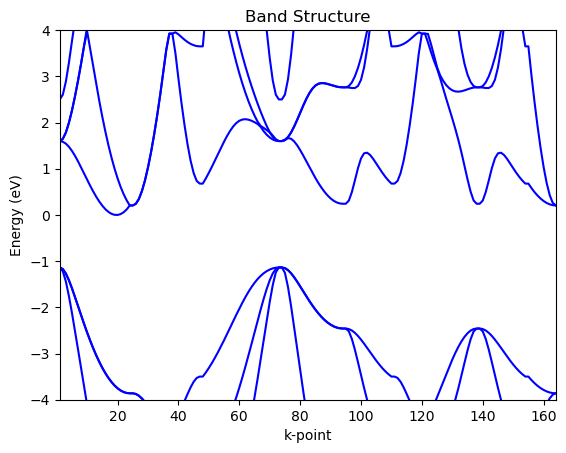

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

###extract the fermi level in eV###
fermi_file_path = "./detailed.out"

# Read file content
with open(fermi_file_path, 'r') as file:
    lines = file.readlines()

# Extract numeric value in eV using regex
fermi_eV = None
for line in lines:
    if 'Fermi' in line and 'eV' in line:
        match = re.search(r'([-+]?\d*\.\d+|\d+)\s*eV', line)
        if match:
            fermi_eV = float(match.group(1))
        break

# Load the data
file_path = "band_tot.dat"
data = pd.read_csv(file_path, delim_whitespace=True, header=None)

# Separate x and y values
x = np.array(data.iloc[:, 0])
y_values = np.array(data.iloc[:, 1:])-fermi_eV

# Plotting
for i in range(y_values.shape[1]):
    plt.plot(x, y_values[:, i], color='blue')

plt.xlim(x[0], x[-1])
plt.ylim(-4, 4)
plt.xlabel('k-point')
plt.ylabel('Energy (eV)')
plt.title('Band Structure')
plt.savefig('dftb_band.png', bbox_inches='tight')


In [4]:
# Re-import necessary libraries after state reset
import re
fermi_file_path = "./detailed.out"

# Read file content
with open(fermi_file_path, 'r') as file:
    lines = file.readlines()

# Extract numeric value in eV using regex
fermi_eV = None
for line in lines:
    if 'Fermi' in line and 'eV' in line:
        match = re.search(r'([-+]?\d*\.\d+|\d+)\s*eV', line)
        if match:
            fermi_eV = float(match.group(1))
        break

fermi_eV

-3.1238